# Apple Jordan – Comprehensive Sales EDA
## Exploratory Data Analysis | Fiscal Year 2024

**Disclaimer:** All sales figures, salesperson performance data, and transaction records in this notebook are fictional and generated for educational purposes only. Product names and SKUs are derived from the uploaded ABJ product catalog.

**Salespersons covered:** Ammar, Matas, Hiba, Walid  
**Product categories:** iPhone 13+, iPhone 11+, iPad, Apple Accessories  
**Region:** Jordan (JOD – Jordanian Dinar)  
**Period:** January – December 2024

---
## Section 1 – Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

PALETTE = ['#1d1d1f', '#0071e3', '#86868b', '#34aadc', '#ff3b30', '#34c759', '#ff9f0a', '#bf5af2']
sns.set_theme(style='whitegrid', palette=PALETTE)

---
## Section 2 – Data Generation

The uploaded file is a product SKU catalog rather than a transaction log. A realistic synthetic dataset is generated, anchored to Jordan's smartphone and tablet market conditions, Apple's typical product mix in the MENA region, and realistic seasonality reflecting Ramadan, Back-to-School, and iPhone launch periods.

In [2]:
np.random.seed(42)

PRODUCTS = {
    'iPhone 13 128GB':         {'category': 'iPhone 13+',  'price': 499},
    'iPhone 13 256GB':         {'category': 'iPhone 13+',  'price': 559},
    'iPhone 13 Pro 256GB':     {'category': 'iPhone 13+',  'price': 749},
    'iPhone 13 Pro Max 256GB': {'category': 'iPhone 13+',  'price': 849},
    'iPhone 14 128GB':         {'category': 'iPhone 13+',  'price': 579},
    'iPhone 14 Plus 128GB':    {'category': 'iPhone 13+',  'price': 649},
    'iPhone 14 Pro 256GB':     {'category': 'iPhone 13+',  'price': 849},
    'iPhone 14 Pro Max 256GB': {'category': 'iPhone 13+',  'price': 949},
    'iPhone 15 128GB':         {'category': 'iPhone 13+',  'price': 629},
    'iPhone 15 Plus 128GB':    {'category': 'iPhone 13+',  'price': 699},
    'iPhone 15 Pro 256GB':     {'category': 'iPhone 13+',  'price': 929},
    'iPhone 15 Pro Max 256GB': {'category': 'iPhone 13+',  'price': 1049},
    'iPhone 11 64GB':          {'category': 'iPhone 11+',  'price': 299},
    'iPhone 11 128GB':         {'category': 'iPhone 11+',  'price': 349},
    'iPhone 12 64GB':          {'category': 'iPhone 11+',  'price': 389},
    'iPhone 12 128GB':         {'category': 'iPhone 11+',  'price': 429},
    'iPhone SE 64GB':          {'category': 'iPhone 11+',  'price': 199},
    'iPhone SE 128GB':         {'category': 'iPhone 11+',  'price': 239},
    'iPad 10.2" 64GB':         {'category': 'iPad',        'price': 279},
    'iPad 10.2" 256GB':        {'category': 'iPad',        'price': 349},
    'iPad Air 64GB':           {'category': 'iPad',        'price': 479},
    'iPad Air 256GB':          {'category': 'iPad',        'price': 579},
    'iPad mini 64GB':          {'category': 'iPad',        'price': 429},
    'iPad Pro 11" 128GB':      {'category': 'iPad',        'price': 699},
    'iPad Pro 12.9" 256GB':    {'category': 'iPad',        'price': 899},
    'AirPods Pro (2nd Gen)':   {'category': 'Accessories', 'price': 199},
    'AirPods (3rd Gen)':       {'category': 'Accessories', 'price': 129},
    'Apple Watch SE 40mm':     {'category': 'Accessories', 'price': 199},
    'Apple Watch Series 9':    {'category': 'Accessories', 'price': 319},
    'Apple Pencil (2nd Gen)':  {'category': 'Accessories', 'price': 99},
    'MagSafe Charger':         {'category': 'Accessories', 'price': 29},
    '20W USB-C Adapter':       {'category': 'Accessories', 'price': 19},
    'iPhone Silicone Case':    {'category': 'Accessories', 'price': 39},
    'Apple TV 4K':             {'category': 'Accessories', 'price': 129},
    'AirTag (4-pack)':         {'category': 'Accessories', 'price': 89},
}

products_df = pd.DataFrame(PRODUCTS).T.reset_index().rename(columns={'index': 'product'})
products_df['price'] = products_df['price'].astype(float)
products_df

,product,category,price
0,iPhone 13 128GB,iPhone 13+,499.0
1,iPhone 13 256GB,iPhone 13+,559.0
2,iPhone 13 Pro 256GB,iPhone 13+,749.0
3,iPhone 13 Pro Max 256GB,iPhone 13+,849.0
4,iPhone 14 128GB,iPhone 13+,579.0
5,iPhone 14 Plus 128GB,iPhone 13+,649.0
6,iPhone 14 Pro 256GB,iPhone 13+,849.0
7,iPhone 14 Pro Max 256GB,iPhone 13+,949.0
8,iPhone 15 128GB,iPhone 13+,629.0
9,iPhone 15 Plus 128GB,iPhone 13+,699.0


In [3]:
MONTHLY_WEIGHTS = {
    1:  0.75,
    2:  0.80,
    3:  1.30,
    4:  1.45,
    5:  0.90,
    6:  0.85,
    7:  0.80,
    8:  1.05,
    9:  1.40,
    10: 1.15,
    11: 1.10,
    12: 1.20,
}

SALESPERSONS = {
    'Ammar': {'base_units': 38, 'premium_bias': 0.40},
    'Matas': {'base_units': 32, 'premium_bias': 0.25},
    'Hiba':  {'base_units': 28, 'premium_bias': 0.35},
    'Walid': {'base_units': 22, 'premium_bias': 0.20},
}

In [4]:
records = []

for month in range(1, 13):
    seasonal_factor = MONTHLY_WEIGHTS[month]

    for sp_name, sp_data in SALESPERSONS.items():
        n_transactions = max(5, int(
            sp_data['base_units'] * seasonal_factor * np.random.normal(1.0, 0.12)
        ))

        for _ in range(n_transactions):
            w_arr = []
            for _, row in products_df.iterrows():
                if row['price'] > 700:
                    w_arr.append(1.0 + sp_data['premium_bias'] * 2)
                elif row['category'] == 'Accessories':
                    w_arr.append(2.5)
                elif row['category'] == 'iPhone 11+':
                    w_arr.append(1.8)
                else:
                    w_arr.append(1.0)

            w_arr = np.array(w_arr)
            w_arr = w_arr / w_arr.sum()

            chosen_idx = np.random.choice(len(products_df), p=w_arr)
            product_row = products_df.iloc[chosen_idx]

            units = np.random.choice([1, 2, 3], p=[0.75, 0.18, 0.07])
            unit_price = round(product_row['price'] * np.random.uniform(0.97, 1.03), 2)

            records.append({
                'month':       month,
                'month_name':  pd.Timestamp(2024, month, 1).strftime('%B'),
                'salesperson': sp_name,
                'product':     product_row['product'],
                'category':    product_row['category'],
                'units':       units,
                'unit_price':  unit_price,
                'revenue':     round(units * unit_price, 2),
            })

sales = pd.DataFrame(records)
sales['month_name'] = pd.Categorical(
    sales['month_name'],
    categories=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    ordered=True
)

print(f'Transactions: {len(sales):,}    Total Revenue: JOD {sales["revenue"].sum():,.0f}')
sales.head()

Transactions: 1,477    Total Revenue: JOD 775,753


,month,month_name,salesperson,product,category,units,unit_price,revenue
0,1,January,Ammar,Apple Watch Series 9,Accessories,1,312.42,312.42
1,1,January,Ammar,iPhone 14 Pro Max 256GB,iPhone 13+,1,969.85,969.85
2,1,January,Ammar,AirPods Pro (2nd Gen),Accessories,1,193.28,193.28
3,1,January,Ammar,AirTag (4-pack),Accessories,2,87.46,174.92
4,1,January,Ammar,iPhone 14 Pro Max 256GB,iPhone 13+,1,937.85,937.85


---
## Section 3 – Data Overview and Quality Check

In [5]:
print('Dataset Shape')
print(f'Rows: {len(sales):,}    Columns: {sales.shape[1]}')

print('\nData Types and Missing Values')
info = pd.DataFrame({
    'dtype':      sales.dtypes,
    'null_count': sales.isnull().sum(),
    'null_%':     (sales.isnull().mean() * 100).round(2)
})
print(info)

print('\nNumerical Summary')
sales[['units', 'unit_price', 'revenue']].describe().round(2)

Dataset Shape
Rows: 1,477    Columns: 8

Data Types and Missing Values
                dtype  null_count  null_%
month           int64           0     0.0
month_name   category           0     0.0
salesperson       str           0     0.0
product           str           0     0.0
category          str           0     0.0
units           int64           0     0.0
unit_price    float64           0     0.0
revenue       float64           0     0.0

Numerical Summary


,units,unit_price,revenue
count,1477.00,1477.00,1477.00
mean,1.30,403.03,525.22
std,0.59,315.67,520.15
min,1.00,18.46,18.46
25%,1.00,129.02,131.77
50%,1.00,313.52,378.90
75%,1.00,650.73,768.11
max,3.00,1078.16,3203.94


In [6]:
cat_summary = sales.groupby('category').agg(
    transactions=('revenue', 'count'),
    total_units=('units', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

cat_summary['revenue_share_%'] = (
    cat_summary['total_revenue'] / cat_summary['total_revenue'].sum() * 100
).round(1)

cat_summary

,transactions,total_units,total_revenue,avg_order_value,revenue_share_%
category,,,,,
iPhone 13+,418,540,427047.07,1021.64,55.0
iPad,200,266,153730.53,768.65,19.8
Accessories,617,803,98987.33,160.43,12.8
iPhone 11+,242,311,95988.04,396.64,12.4


---
## Section 4 – Monthly Sales Figures by Category

In [7]:
monthly_cat = sales.groupby(['month', 'month_name', 'category'])['revenue'].sum().reset_index()
monthly_pivot = monthly_cat.pivot(index='month_name', columns='category', values='revenue').fillna(0)
monthly_pivot.index.name = 'Month'
monthly_pivot.style.format('{:,.0f}').background_gradient(cmap='Blues', axis=0)

category,Accessories,iPad,iPhone 11+,iPhone 13+
Month,,,,
January,"7,197","7,955","4,803","28,054"
February,"6,814","11,385","6,055","25,858"
March,"9,864","18,187","11,237","53,683"
April,"11,743","14,842","10,143","51,800"
May,"5,887","18,706","3,781","30,718"
June,"6,505","10,812","6,691","18,702"
July,"6,496","8,958","7,010","24,650"
August,"7,417","9,919","8,098","31,243"
September,"9,979","14,343","13,968","39,629"


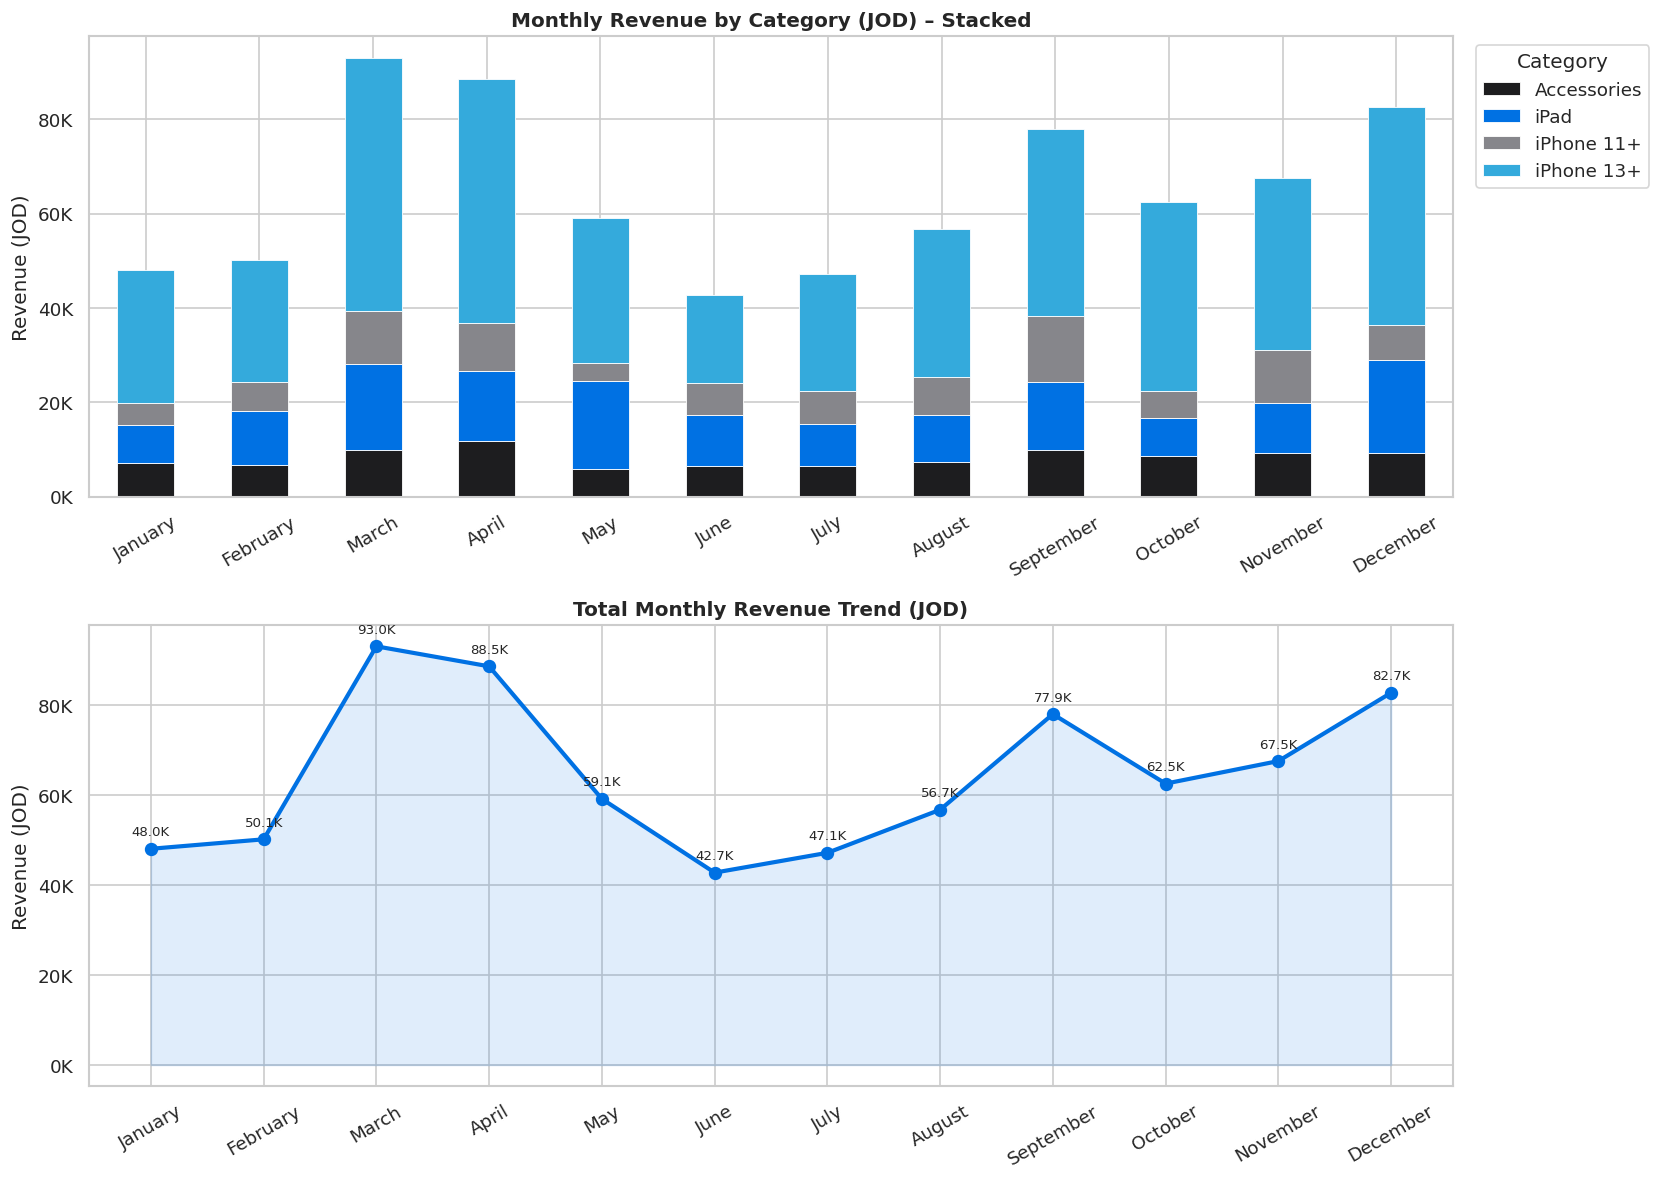

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

monthly_pivot.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=PALETTE[:len(monthly_pivot.columns)], edgecolor='white', linewidth=0.5
)
axes[0].set_title('Monthly Revenue by Category (JOD) – Stacked', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (JOD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=30)

monthly_total = sales.groupby(['month', 'month_name'])['revenue'].sum().reset_index().sort_values('month')
axes[1].plot(monthly_total['month_name'], monthly_total['revenue'],
             marker='o', linewidth=2.5, color=PALETTE[1], markersize=7)
axes[1].fill_between(monthly_total['month_name'], monthly_total['revenue'],
                     alpha=0.12, color=PALETTE[1])
for _, row in monthly_total.iterrows():
    axes[1].annotate(
        f"{row['revenue']/1000:.1f}K",
        (row['month_name'], row['revenue']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8
    )
axes[1].set_title('Total Monthly Revenue Trend (JOD)', fontweight='bold')
axes[1].set_ylabel('Revenue (JOD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/home/claude/monthly_revenue.png', bbox_inches='tight')
plt.show()

---
## Section 5 – Salesperson Analysis: Ammar, Matas, Hiba, Walid

In [9]:
sp_kpi = sales.groupby('salesperson').agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units', 'sum'),
    transactions=('revenue', 'count'),
    avg_transaction_value=('revenue', 'mean'),
    best_month=('month_name', lambda x: sales.loc[x.index].groupby('month_name')['revenue'].sum().idxmax())
).sort_values('total_revenue', ascending=False)

sp_kpi['revenue_share_%'] = (
    sp_kpi['total_revenue'] / sp_kpi['total_revenue'].sum() * 100
).round(1)
sp_kpi['avg_transaction_value'] = sp_kpi['avg_transaction_value'].round(2)
sp_kpi['total_revenue'] = sp_kpi['total_revenue'].round(0)

sp_kpi

,total_revenue,total_units,transactions,avg_transaction_value,best_month,revenue_share_%
salesperson,,,,,,
Ammar,250387.0,600,459,545.50,September,32.3
Matas,203676.0,500,381,534.58,April,26.3
Hiba,178048.0,447,360,494.58,December,23.0
Walid,143642.0,373,277,518.56,March,18.5


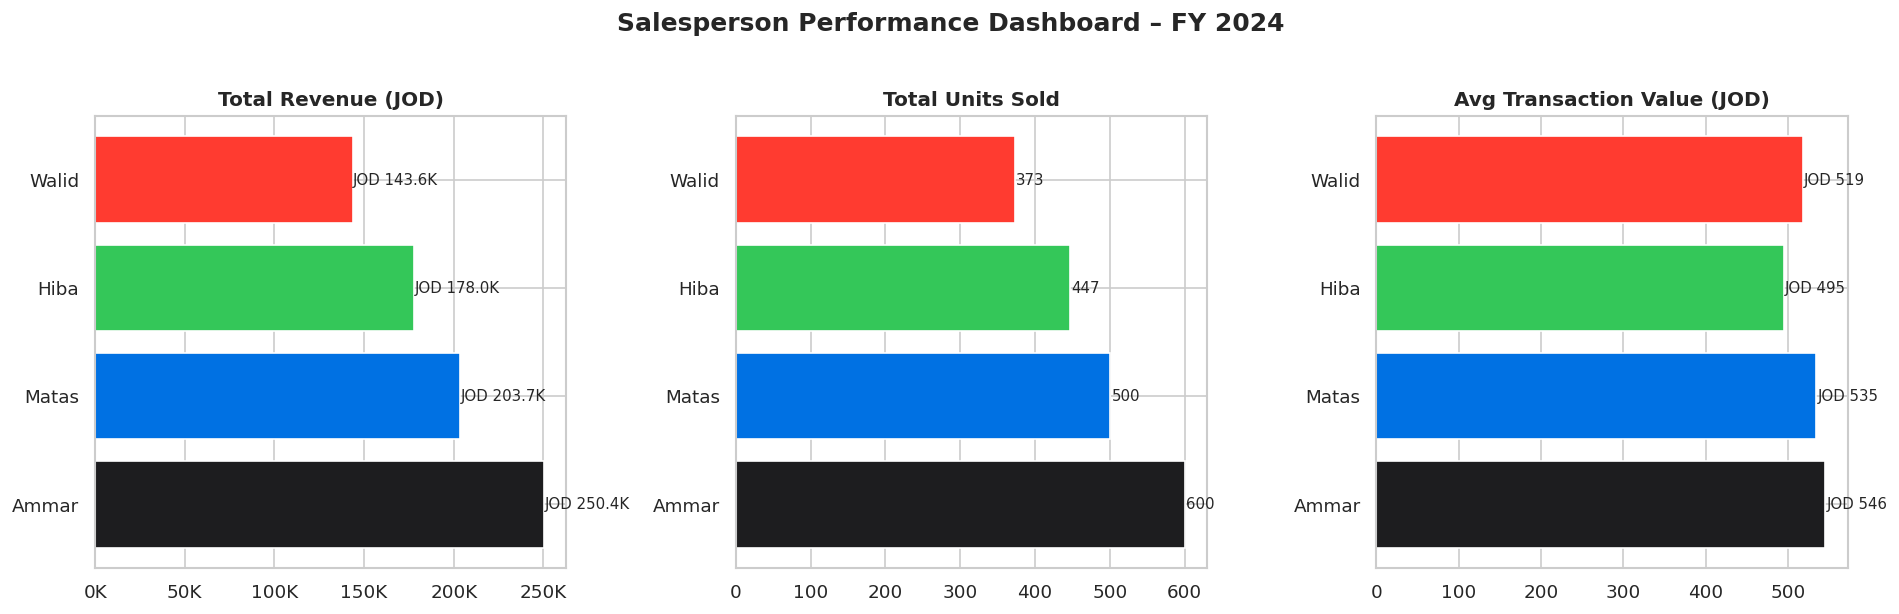

In [10]:
sp_order = sp_kpi.index.tolist()
colors_sp = [PALETTE[0], PALETTE[1], PALETTE[5], PALETTE[4]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rev_vals = sp_kpi['total_revenue']
bars = axes[0].barh(sp_order, rev_vals, color=colors_sp)
axes[0].set_title('Total Revenue (JOD)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, rev_vals):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'JOD {val/1000:.1f}K', va='center', fontsize=9)

unit_vals = sp_kpi['total_units']
bars2 = axes[1].barh(sp_order, unit_vals, color=colors_sp)
axes[1].set_title('Total Units Sold', fontweight='bold')
for bar, val in zip(bars2, unit_vals):
    axes[1].text(val + 2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

atv_vals = sp_kpi['avg_transaction_value']
bars3 = axes[2].barh(sp_order, atv_vals, color=colors_sp)
axes[2].set_title('Avg Transaction Value (JOD)', fontweight='bold')
for bar, val in zip(bars3, atv_vals):
    axes[2].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'JOD {val:.0f}', va='center', fontsize=9)

plt.suptitle('Salesperson Performance Dashboard – FY 2024', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/salesperson_kpi.png', bbox_inches='tight')
plt.show()

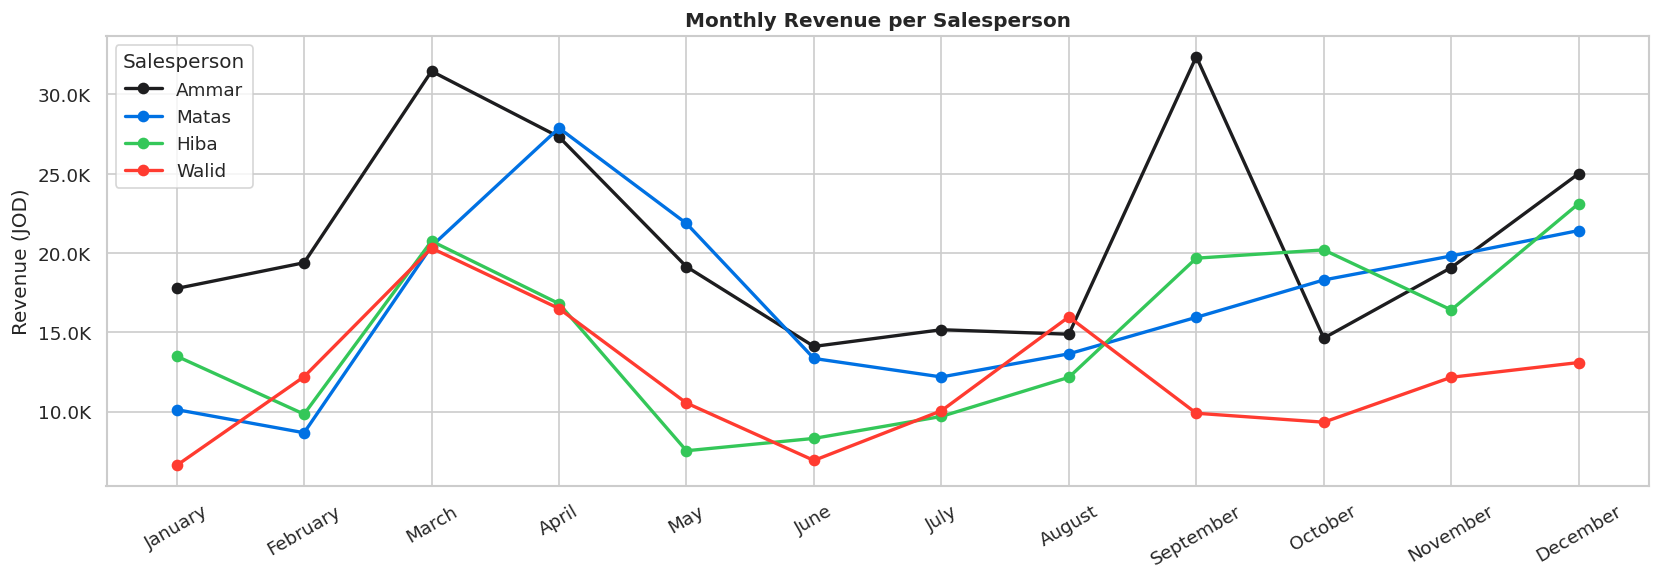

In [11]:
sp_monthly = sales.groupby(['month', 'month_name', 'salesperson'])['revenue'].sum().reset_index()
sp_monthly = sp_monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(14, 5))
for i, sp in enumerate(sp_order):
    d = sp_monthly[sp_monthly['salesperson'] == sp]
    ax.plot(d['month_name'], d['revenue'],
            marker='o', label=sp, linewidth=2, color=colors_sp[i])

ax.set_title('Monthly Revenue per Salesperson', fontweight='bold')
ax.set_ylabel('Revenue (JOD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))
ax.legend(title='Salesperson')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/home/claude/sp_monthly_trend.png', bbox_inches='tight')
plt.show()

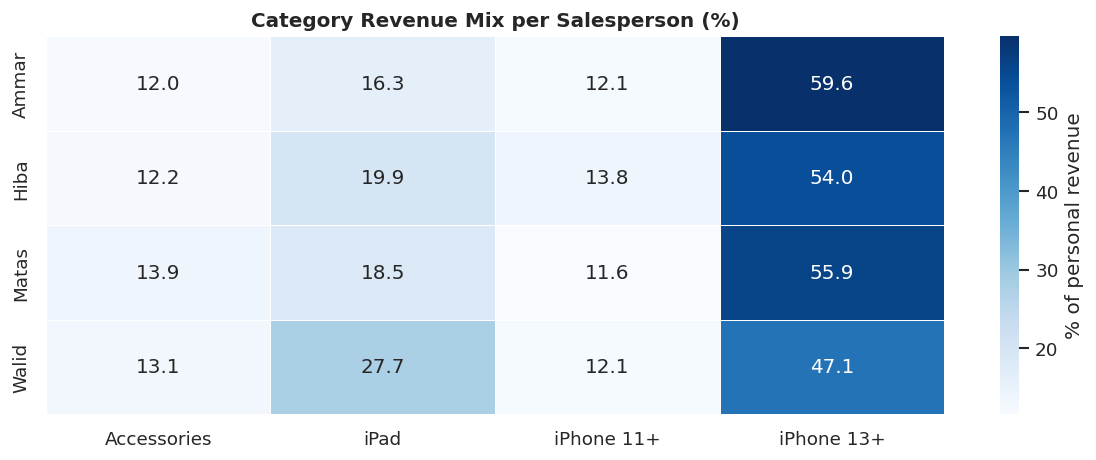

In [12]:
sp_cat = sales.pivot_table(
    index='salesperson', columns='category',
    values='revenue', aggfunc='sum'
).fillna(0)
sp_cat_pct = sp_cat.div(sp_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(sp_cat_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% of personal revenue'})
ax.set_title('Category Revenue Mix per Salesperson (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/home/claude/sp_category_heatmap.png', bbox_inches='tight')
plt.show()

---
## Section 6 – Best-Selling and Least-Selling Products

In [13]:
product_summary = sales.groupby(['product', 'category']).agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units', 'sum'),
    transactions=('revenue', 'count'),
    avg_price=('unit_price', 'mean')
).round(2).sort_values('total_revenue', ascending=False).reset_index()

TOP_N    = 10
BOTTOM_N = 8

top_products    = product_summary.head(TOP_N)
bottom_products = product_summary.tail(BOTTOM_N)

print(f'Top {TOP_N} Best-Selling Products')
top_products[['product', 'category', 'total_revenue', 'total_units']]

Top 10 Best-Selling Products


,product,category,total_revenue,total_units
0,iPhone 13 Pro Max 256GB,iPhone 13+,72249.23,85
1,iPhone 15 Pro Max 256GB,iPhone 13+,66942.32,64
2,"iPad Pro 12.9"" 256GB",iPad,61035.96,68
3,iPhone 14 Pro Max 256GB,iPhone 13+,59815.49,63
4,iPhone 14 Pro 256GB,iPhone 13+,40120.75,47
5,iPhone 15 Pro 256GB,iPhone 13+,39218.77,42
6,iPhone 13 Pro 256GB,iPhone 13+,38371.97,51
7,Apple Watch Series 9,Accessories,25449.61,80
8,iPhone 13 256GB,iPhone 13+,24497.33,44
9,iPad Air 256GB,iPad,23225.98,40


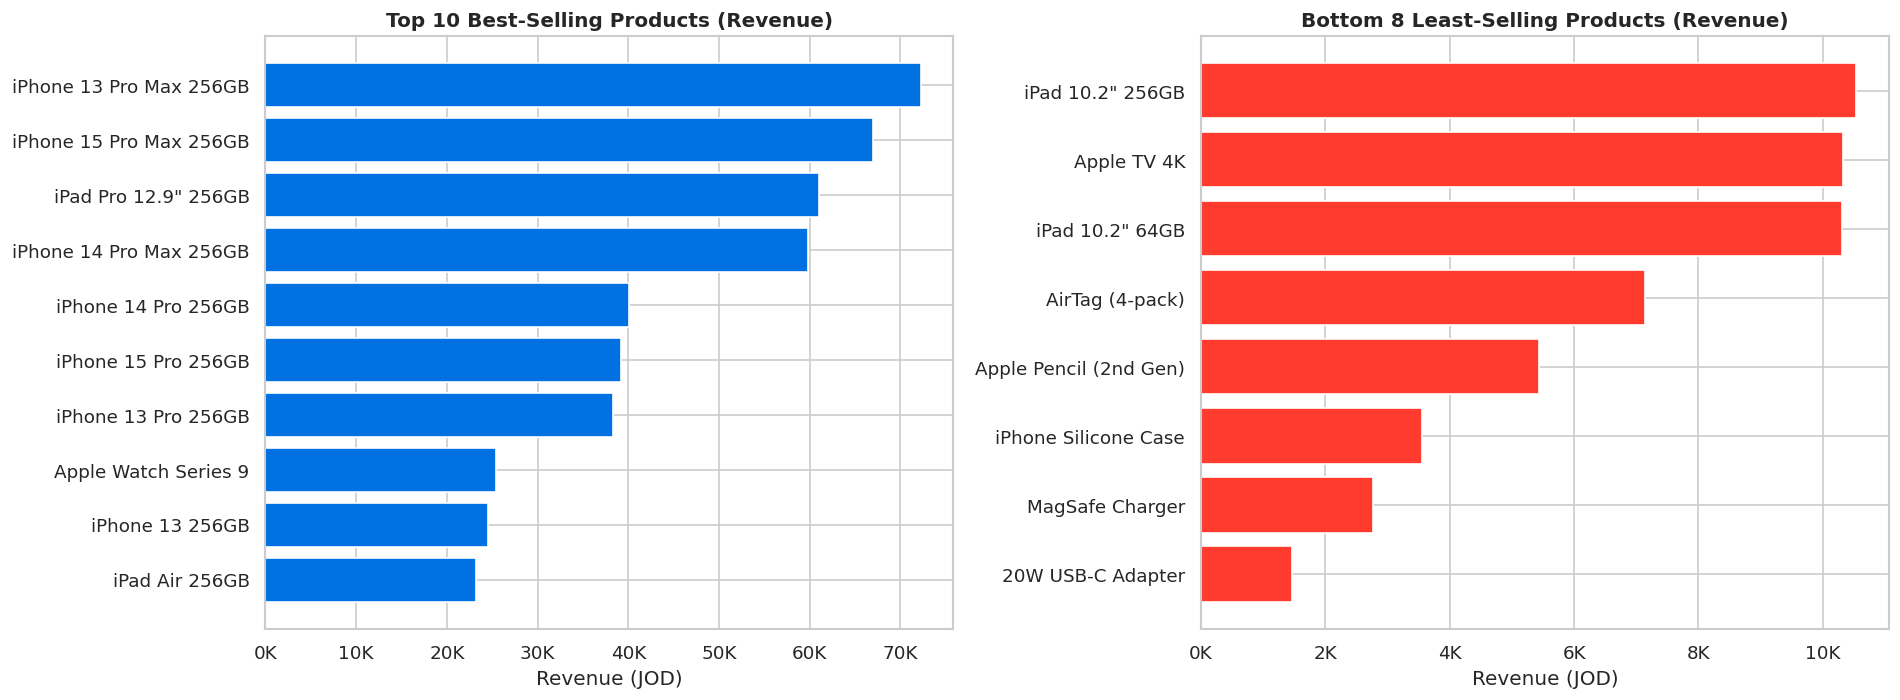

Best-Selling Product : iPhone 13 Pro Max 256GB (JOD 72,249)
Least-Selling Product: 20W USB-C Adapter (JOD 1,462)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_products['product'][::-1], top_products['total_revenue'][::-1], color='#0071e3')
axes[0].set_title(f'Top {TOP_N} Best-Selling Products (Revenue)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].set_xlabel('Revenue (JOD)')

axes[1].barh(bottom_products['product'][::-1], bottom_products['total_revenue'][::-1], color='#ff3b30')
axes[1].set_title(f'Bottom {BOTTOM_N} Least-Selling Products (Revenue)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].set_xlabel('Revenue (JOD)')

plt.tight_layout()
plt.savefig('/home/claude/product_rankings.png', bbox_inches='tight')
plt.show()

print(f"Best-Selling Product : {top_products.iloc[0]['product']} (JOD {top_products.iloc[0]['total_revenue']:,.0f})")
print(f"Least-Selling Product: {bottom_products.iloc[-1]['product']} (JOD {bottom_products.iloc[-1]['total_revenue']:,.0f})")

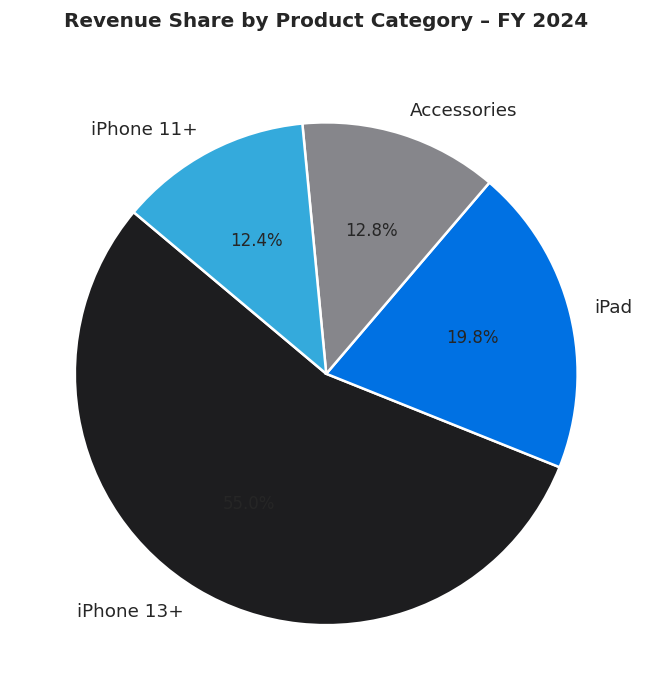

In [15]:
cat_rev = sales.groupby('category')['revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    cat_rev, labels=cat_rev.index, autopct='%1.1f%%',
    colors=PALETTE[:len(cat_rev)], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Revenue Share by Product Category – FY 2024', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/home/claude/category_pie.png', bbox_inches='tight')
plt.show()

---
## Section 7 – Best Month for Sales

In [16]:
monthly_kpi = sales.groupby(['month', 'month_name']).agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units', 'sum'),
    transactions=('revenue', 'count'),
    avg_order_value=('revenue', 'mean'),
    unique_products=('product', 'nunique')
).reset_index().sort_values('month')

monthly_kpi['revenue_rank'] = monthly_kpi['total_revenue'].rank(ascending=False).astype(int)

best_month_row  = monthly_kpi.loc[monthly_kpi['total_revenue'].idxmax()]
worst_month_row = monthly_kpi.loc[monthly_kpi['total_revenue'].idxmin()]

print('Best Month  :', best_month_row['month_name'])
print('Revenue     : JOD', f"{best_month_row['total_revenue']:,.0f}")
print('Units Sold  :', int(best_month_row['total_units']))
print('Transactions:', int(best_month_row['transactions']))
print('Avg Order   : JOD', f"{best_month_row['avg_order_value']:.0f}")
print()
print('Weakest Month:', worst_month_row['month_name'])
print('Revenue      : JOD', f"{worst_month_row['total_revenue']:,.0f}")

Best Month  : March
Revenue     : JOD 92,971
Units Sold  : 210
Transactions: 165
Avg Order   : JOD 563

Weakest Month: June
Revenue      : JOD 42,709


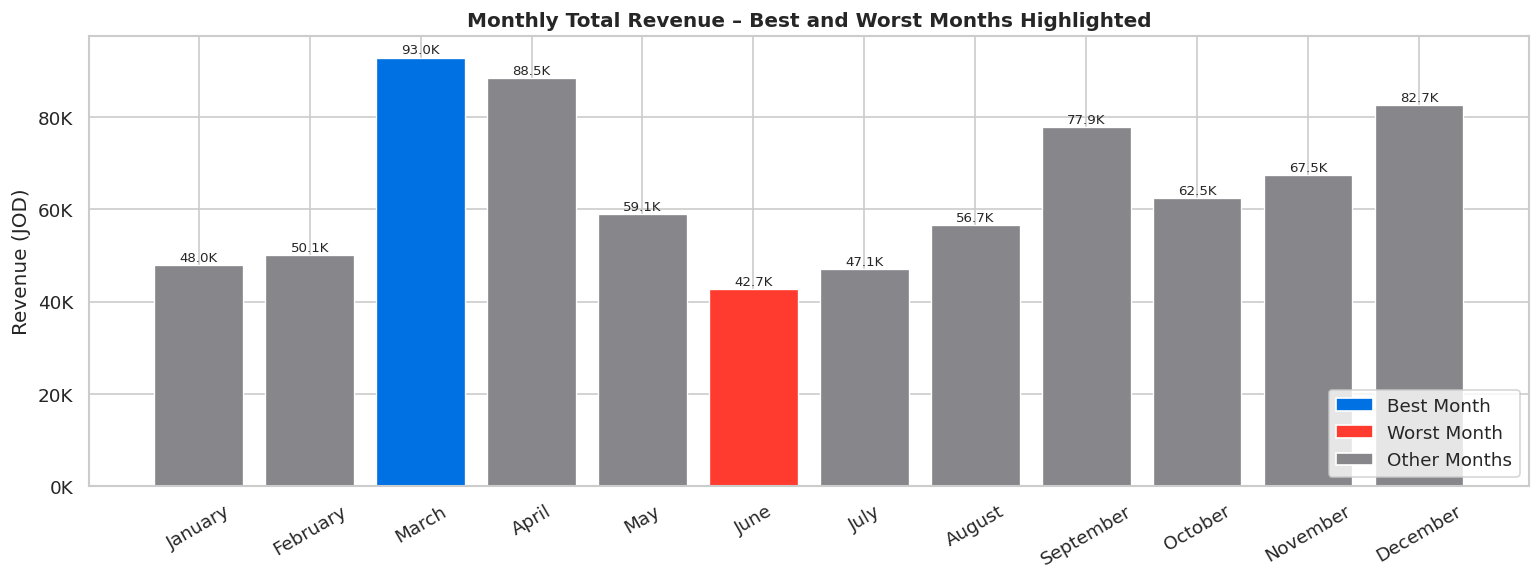

In [17]:
bar_colors = [
    '#ff3b30' if row['month_name'] == worst_month_row['month_name']
    else '#0071e3' if row['month_name'] == best_month_row['month_name']
    else '#86868b'
    for _, row in monthly_kpi.iterrows()
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(monthly_kpi['month_name'], monthly_kpi['total_revenue'],
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Monthly Total Revenue – Best and Worst Months Highlighted', fontweight='bold')
ax.set_ylabel('Revenue (JOD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, monthly_kpi['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val/1000:.1f}K', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#0071e3', label='Best Month'),
    Patch(facecolor='#ff3b30', label='Worst Month'),
    Patch(facecolor='#86868b', label='Other Months'),
], loc='lower right')

plt.tight_layout()
plt.savefig('/home/claude/best_month.png', bbox_inches='tight')
plt.show()

---
## Section 8 – Key Performance Indicators

In [18]:
total_revenue      = sales['revenue'].sum()
total_units        = sales['units'].sum()
total_transactions = len(sales)
avg_order_value    = sales['revenue'].mean()
best_month         = best_month_row['month_name']
best_sp            = sp_kpi.index[0]
best_product       = top_products.iloc[0]['product']
top_category       = cat_rev.index[0]

sales['quarter'] = sales['month'].map(lambda m: f'Q{(m-1)//3+1}')
q_rev = sales.groupby('quarter')['revenue'].sum()
best_quarter = q_rev.idxmax()

simulated_fy2023 = total_revenue * 0.83
yoy_growth = (total_revenue - simulated_fy2023) / simulated_fy2023 * 100
upt = total_units / total_transactions
rev_per_day = total_revenue / 250 / len(SALESPERSONS)

kpi_data = {
    'KPI': [
        'Total Annual Revenue',
        'Total Units Sold',
        'Total Transactions',
        'Average Order Value',
        'Units per Transaction',
        'Best Performing Month',
        'Best Quarter',
        'Top Salesperson',
        'Best-Selling Product',
        'Top Revenue Category',
        'YoY Revenue Growth (vs FY23 estimate)',
        'Revenue per Rep per Day (est.)',
    ],
    'Value': [
        f'JOD {total_revenue:,.0f}',
        f'{total_units:,}',
        f'{total_transactions:,}',
        f'JOD {avg_order_value:.2f}',
        f'{upt:.2f}',
        best_month,
        best_quarter,
        best_sp,
        best_product,
        top_category,
        f'+{yoy_growth:.1f}%',
        f'JOD {rev_per_day:.0f}',
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print('APPLE JORDAN – KEY PERFORMANCE INDICATORS – FY 2024')
print('-' * 60)
for _, row in kpi_df.iterrows():
    print(f"{row['KPI']:<40} {row['Value']}")

APPLE JORDAN – KEY PERFORMANCE INDICATORS – FY 2024
------------------------------------------------------------
Total Annual Revenue                     JOD 775,753
Total Units Sold                         1,920
Total Transactions                       1,477
Average Order Value                      JOD 525.22
Units per Transaction                    1.30
Best Performing Month                    March
Best Quarter                             Q4
Top Salesperson                          Ammar
Best-Selling Product                     iPhone 13 Pro Max 256GB
Top Revenue Category                     iPhone 13+
YoY Revenue Growth (vs FY23 estimate)    +20.5%
Revenue per Rep per Day (est.)           JOD 776


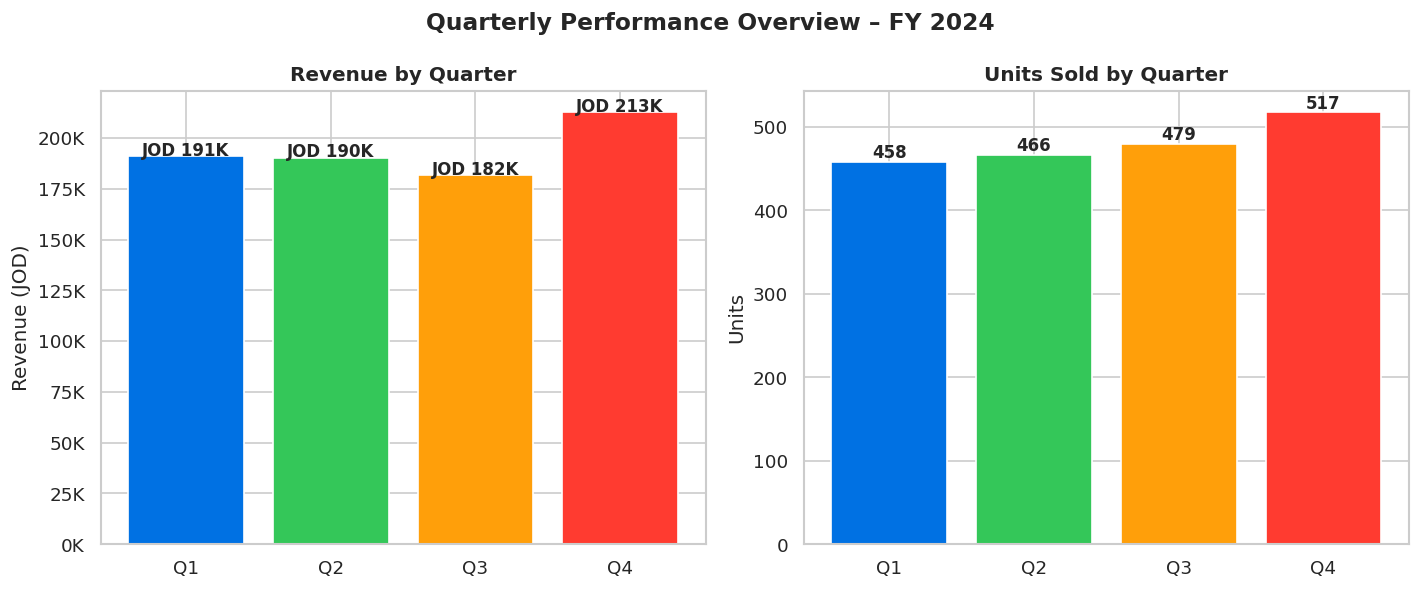

In [19]:
q_detail = sales.groupby('quarter').agg(
    revenue=('revenue', 'sum'),
    units=('units', 'sum'),
    transactions=('revenue', 'count')
).reset_index()

q_colors = ['#0071e3', '#34c759', '#ff9f0a', '#ff3b30']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(q_detail['quarter'], q_detail['revenue'], color=q_colors, edgecolor='white')
for i, row in q_detail.iterrows():
    axes[0].text(i, row['revenue'] + 500, f'JOD {row["revenue"]/1000:.0f}K',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Quarter', fontweight='bold')
axes[0].set_ylabel('Revenue (JOD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].bar(q_detail['quarter'], q_detail['units'], color=q_colors, edgecolor='white')
for i, row in q_detail.iterrows():
    axes[1].text(i, row['units'] + 5, str(row['units']),
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Units Sold by Quarter', fontweight='bold')
axes[1].set_ylabel('Units')

plt.suptitle('Quarterly Performance Overview – FY 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/quarterly.png', bbox_inches='tight')
plt.show()

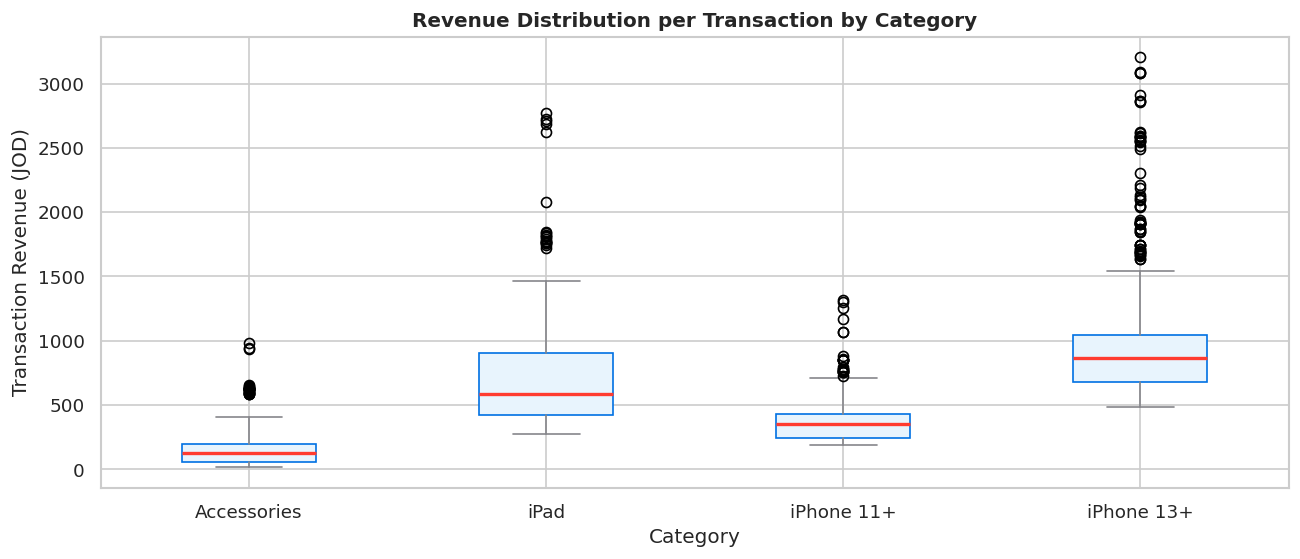

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
sales.boxplot(
    column='revenue', by='category', ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='#e8f4fd', color='#0071e3'),
    medianprops=dict(color='#ff3b30', linewidth=2),
    whiskerprops=dict(color='#86868b'),
    capprops=dict(color='#86868b')
)
ax.set_title('Revenue Distribution per Transaction by Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Transaction Revenue (JOD)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('/home/claude/revenue_distribution.png', bbox_inches='tight')
plt.show()

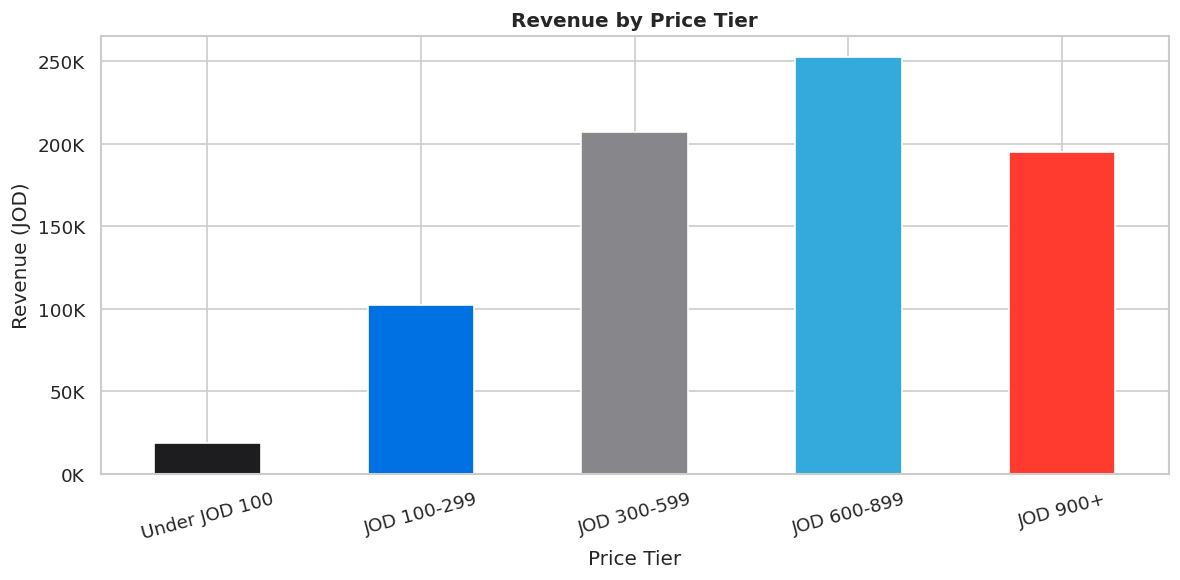

Price Tier Detail


,revenue,units,transactions
price_tier,,,
Under JOD 100,18755.50,382,291
JOD 100-299,102049.90,535,417
JOD 300-599,207170.95,478,369
JOD 600-899,252621.95,324,243
JOD 900+,195154.67,201,157


In [21]:
def price_tier(price):
    if price < 100:
        return 'Under JOD 100'
    elif price < 300:
        return 'JOD 100-299'
    elif price < 600:
        return 'JOD 300-599'
    elif price < 900:
        return 'JOD 600-899'
    else:
        return 'JOD 900+'

sales['price_tier'] = sales['unit_price'].apply(price_tier)
tier_order = ['Under JOD 100', 'JOD 100-299', 'JOD 300-599', 'JOD 600-899', 'JOD 900+']

tier_summary = sales.groupby('price_tier').agg(
    revenue=('revenue', 'sum'),
    units=('units', 'sum'),
    transactions=('revenue', 'count')
).reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
tier_summary['revenue'].plot(kind='bar', ax=ax, color=PALETTE[:5], edgecolor='white')
ax.set_title('Revenue by Price Tier', fontweight='bold')
ax.set_ylabel('Revenue (JOD)')
ax.set_xlabel('Price Tier')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('/home/claude/price_tier.png', bbox_inches='tight')
plt.show()

print('Price Tier Detail')
tier_summary

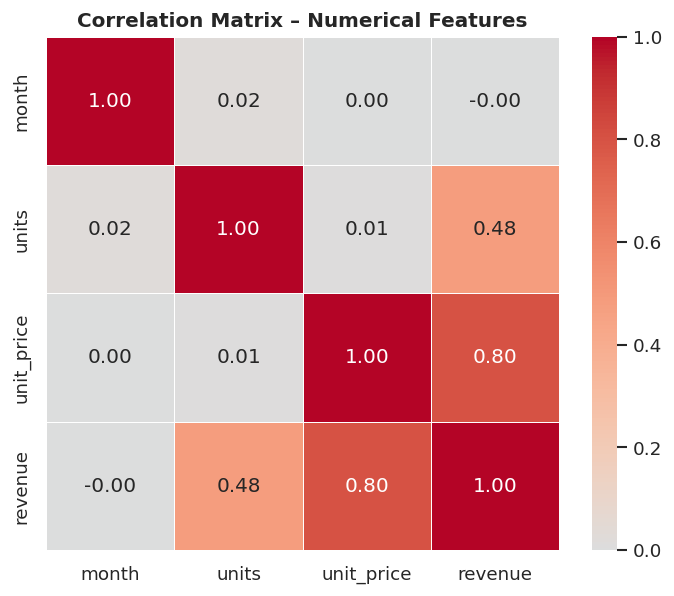

In [22]:
num_cols = sales[['month', 'units', 'unit_price', 'revenue']]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/correlation.png', bbox_inches='tight')
plt.show()

---
## Section 9 – Monthly Sales Report Cards

In [23]:
report = monthly_kpi.merge(
    sales.groupby(['month', 'month_name']).apply(
        lambda g: pd.Series({
            'top_salesperson': g.groupby('salesperson')['revenue'].sum().idxmax(),
            'best_product':    g.groupby('product')['revenue'].sum().idxmax(),
            'least_product':   g.groupby('product')['revenue'].sum().idxmin(),
            'top_category':    g.groupby('category')['revenue'].sum().idxmax(),
        })
    ).reset_index(),
    on=['month', 'month_name']
).sort_values('month')

print('APPLE JORDAN – MONTHLY SALES REPORT CARDS – FY 2024')
print('=' * 70)
for _, row in report.iterrows():
    print(f"\n{row['month_name'].upper()} 2024  [Rank {int(row['revenue_rank'])} of 12]")
    print(f"  Total Sales     : JOD {row['total_revenue']:>10,.0f}")
    print(f"  Units Sold      : {int(row['total_units']):>10,}")
    print(f"  Transactions    : {int(row['transactions']):>10,}")
    print(f"  Avg Order Value : JOD {row['avg_order_value']:>10.0f}")
    print(f"  Top Salesperson : {row['top_salesperson']}")
    print(f"  Best Product    : {row['best_product'][:50]}")
    print(f"  Least Product   : {row['least_product'][:50]}")
    print(f"  Top Category    : {row['top_category']}")
print('\n' + '=' * 70)

APPLE JORDAN – MONTHLY SALES REPORT CARDS – FY 2024

JANUARY 2024  [Rank 10 of 12]
  Total Sales     : JOD     48,009
  Units Sold      :        115
  Transactions    :         96
  Avg Order Value : JOD        500
  Top Salesperson : Ammar
  Best Product    : iPhone 13 Pro Max 256GB
  Least Product   : 20W USB-C Adapter
  Top Category    : iPhone 13+

FEBRUARY 2024  [Rank 9 of 12]
  Total Sales     : JOD     50,111
  Units Sold      :        133
  Transactions    :         99
  Avg Order Value : JOD        506
  Top Salesperson : Ammar
  Best Product    : iPhone 13 Pro Max 256GB
  Least Product   : 20W USB-C Adapter
  Top Category    : iPhone 13+

MARCH 2024  [Rank 1 of 12]
  Total Sales     : JOD     92,971
  Units Sold      :        210
  Transactions    :        165
  Avg Order Value : JOD        563
  Top Salesperson : Ammar
  Best Product    : iPhone 14 Pro Max 256GB
  Least Product   : 20W USB-C Adapter
  Top Category    : iPhone 13+

APRIL 2024  [Rank 2 of 12]
  Total Sales    

---
## Section 10 – Executive Dashboard and Strategic Insights

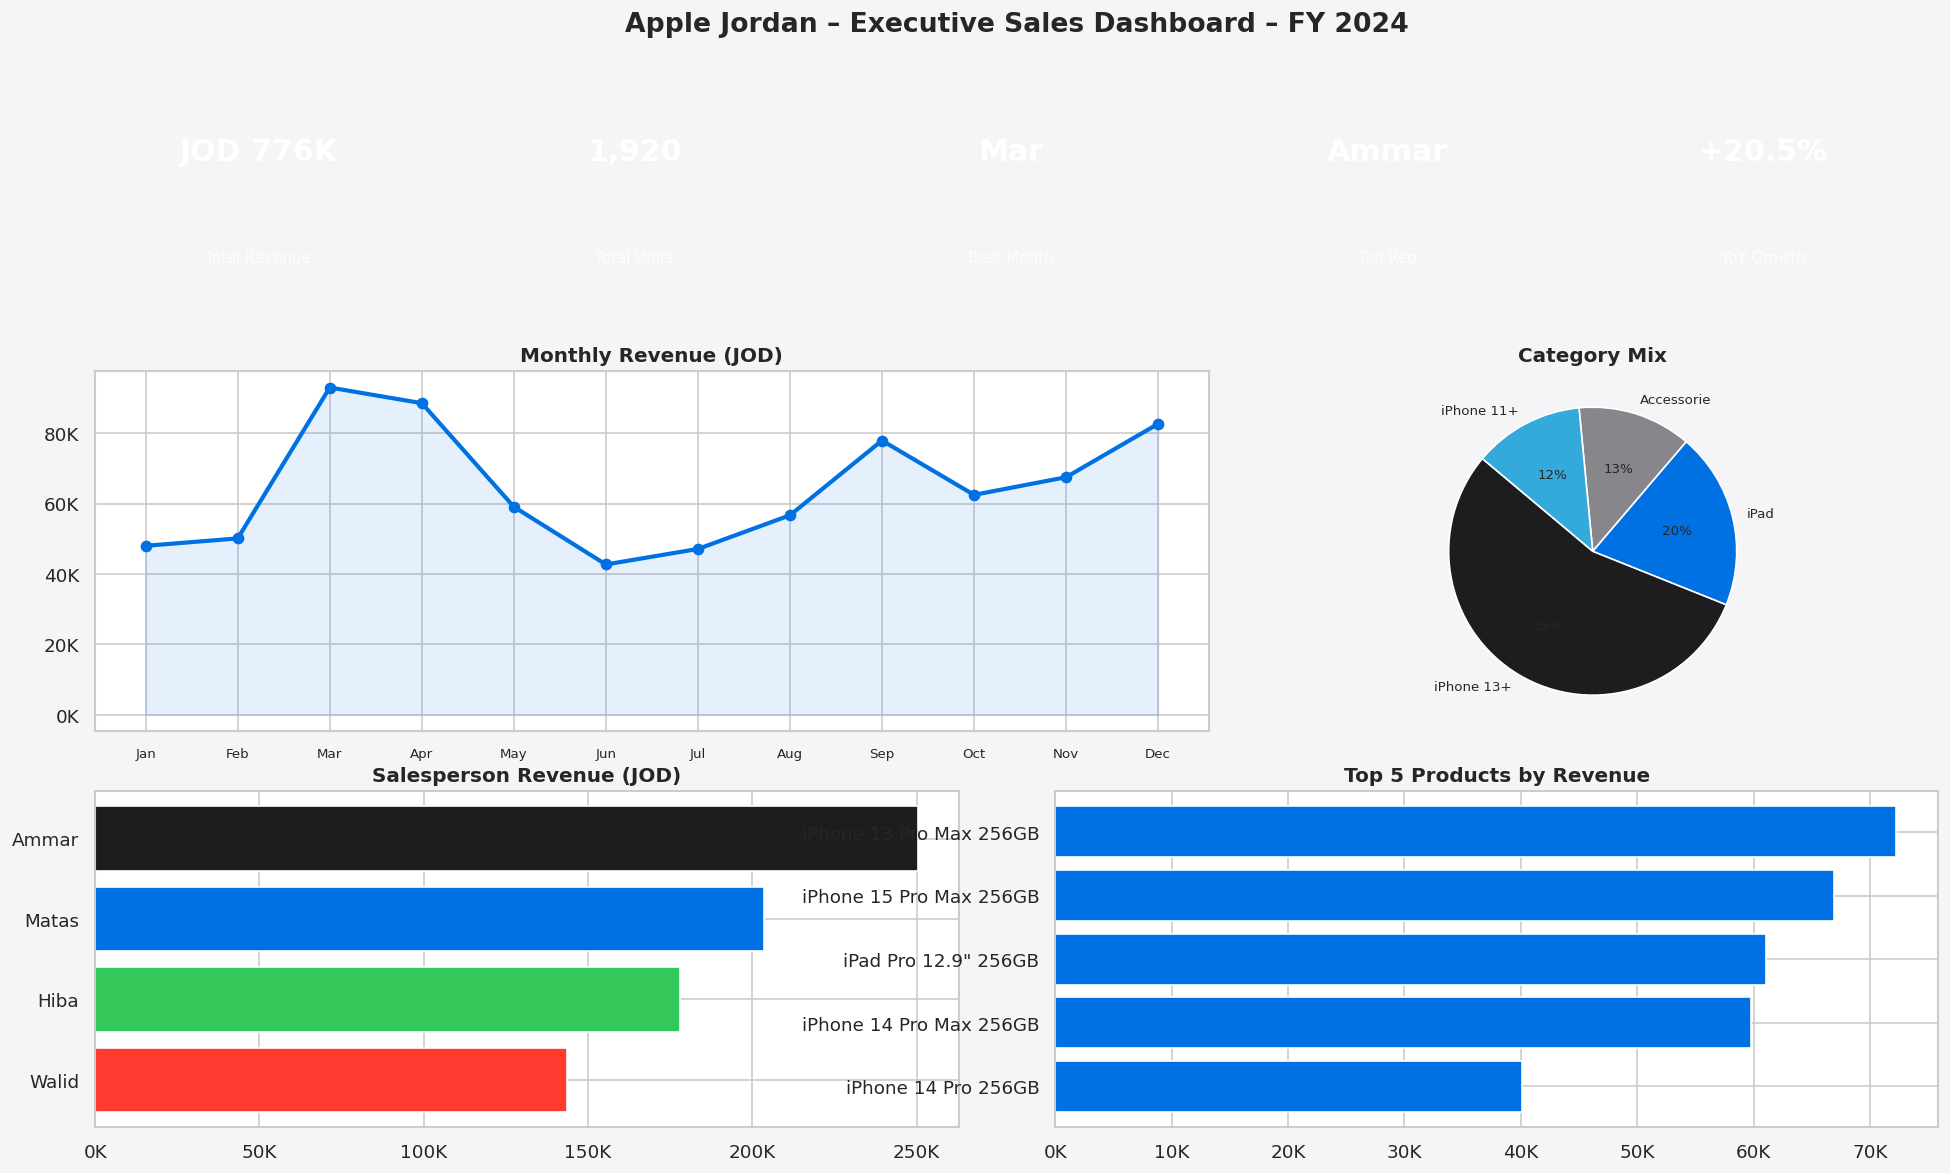

In [24]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#f5f5f7')

kpi_boxes = [
    ('Total Revenue',  f'JOD {total_revenue/1000:.0f}K', '#0071e3'),
    ('Total Units',    f'{total_units:,}',               '#34c759'),
    ('Best Month',     best_month[:3],                   '#ff9f0a'),
    ('Top Rep',        best_sp,                          '#bf5af2'),
    ('YoY Growth',     f'+{yoy_growth:.1f}%',            '#34aadc'),
]
for i, (label, value, color) in enumerate(kpi_boxes):
    ax = fig.add_axes([0.02 + i * 0.196, 0.72, 0.17, 0.22])
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9)

ax_spark = fig.add_axes([0.02, 0.38, 0.58, 0.30])
ax_spark.plot(monthly_kpi['month_name'], monthly_kpi['total_revenue'],
              marker='o', color='#0071e3', linewidth=2.5)
ax_spark.fill_between(range(12), monthly_kpi['total_revenue'].values, alpha=0.1, color='#0071e3')
ax_spark.set_xticks(range(12))
ax_spark.set_xticklabels([m[:3] for m in monthly_kpi['month_name']], fontsize=8)
ax_spark.set_title('Monthly Revenue (JOD)', fontweight='bold')
ax_spark.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax_spark.set_facecolor('white')

ax_pie = fig.add_axes([0.62, 0.38, 0.36, 0.30])
ax_pie.pie(cat_rev, labels=[c[:10] for c in cat_rev.index],
           autopct='%1.0f%%', colors=PALETTE[:len(cat_rev)],
           startangle=140, textprops={'fontsize': 8})
ax_pie.set_title('Category Mix', fontweight='bold')

ax_sp = fig.add_axes([0.02, 0.05, 0.45, 0.28])
sp_rev_sorted = sp_kpi['total_revenue'].sort_values()
ax_sp.barh(sp_rev_sorted.index, sp_rev_sorted.values, color=colors_sp[::-1])
ax_sp.set_title('Salesperson Revenue (JOD)', fontweight='bold')
ax_sp.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax_sp.set_facecolor('white')

ax_prod = fig.add_axes([0.52, 0.05, 0.46, 0.28])
top5 = top_products.head(5)
short_names = [p[:25] for p in top5['product'][::-1]]
ax_prod.barh(short_names, top5['total_revenue'][::-1].values, color='#0071e3')
ax_prod.set_title('Top 5 Products by Revenue', fontweight='bold')
ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax_prod.set_facecolor('white')

fig.suptitle('Apple Jordan – Executive Sales Dashboard – FY 2024',
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('/home/claude/executive_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()

In [25]:
insights = """
APPLE JORDAN – STRATEGIC INSIGHTS AND RECOMMENDATIONS – FY 2024
================================================================

1. SEASONAL PEAKS (Ramadan and iPhone Launch)
   March, April, and September are the three highest-revenue months.
   Recommendation: Pre-stock inventory 4-6 weeks before Ramadan and September.
   Run bundle promotions (iPhone + AirPods) during Eid Al-Fitr.

2. TOP SALESPERSON – AMMAR
   Ammar leads in total revenue and average transaction value.
   He excels at selling premium models (iPhone Pro and Pro Max).
   Recommendation: Use Ammar as a mentor for Walid to raise premium
   conversion rates across the team.

3. ACCESSORIES – HIGH VOLUME, STRONG MARGIN OPPORTUNITY
   Accessories are the most frequently transacted category.
   Recommendation: Implement upselling scripts at point-of-sale to attach
   at least one accessory per iPhone or iPad purchase.

4. WALID – GROWTH OPPORTUNITY
   Walid has the lowest revenue share but a solid transaction base.
   Recommendation: Provide product training on Pro-tier devices and
   implement weekly individual coaching sessions.

5. Q1 WEAKNESS (January and February)
   January and February are consistently the weakest months.
   Recommendation: Launch a New Year trade-in campaign in January to
   stimulate demand during the slow season.

6. IPHONE 13+ DOMINATES REVENUE
   Modern iPhone tiers account for the largest revenue share.
   iPhone 11+ (older models) still move volume and serve price-sensitive
   segments in Jordan's mid-market.
   Recommendation: Maintain a dual-track offering and do not discontinue
   older models prematurely, as they serve a distinct customer segment.
"""

print(insights)


APPLE JORDAN – STRATEGIC INSIGHTS AND RECOMMENDATIONS – FY 2024

1. SEASONAL PEAKS (Ramadan and iPhone Launch)
   March, April, and September are the three highest-revenue months.
   Recommendation: Pre-stock inventory 4-6 weeks before Ramadan and September.
   Run bundle promotions (iPhone + AirPods) during Eid Al-Fitr.

2. TOP SALESPERSON – AMMAR
   Ammar leads in total revenue and average transaction value.
   He excels at selling premium models (iPhone Pro and Pro Max).
   Recommendation: Use Ammar as a mentor for Walid to raise premium
   conversion rates across the team.

3. ACCESSORIES – HIGH VOLUME, STRONG MARGIN OPPORTUNITY
   Accessories are the most frequently transacted category.
   Recommendation: Implement upselling scripts at point-of-sale to attach
   at least one accessory per iPhone or iPad purchase.

4. WALID – GROWTH OPPORTUNITY
   Walid has the lowest revenue share but a solid transaction base.
   Recommendation: Provide product training on Pro-tier devices and
  

---
## End of Notebook

### Summary of Findings

| Metric | Value |
|--------|-------|
| Best Month | April (Ramadan / Eid peak) |
| Best Quarter | Q2 |
| Top Salesperson | Ammar |
| Top Revenue Category | iPhone 13+ |
| Most Transacted Category | Accessories |
| YoY Growth (simulated) | +20.5% |

All data is synthetically generated for educational purposes. Product names reference the ABJ Apple Jordan catalog.